In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# !unzip "/content/drive/MyDrive/AI_and_ML/ Week 5 - Introduction to CNN/FruitinAmazon.zip"

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report

In [38]:
import os
import random
import numpy as np
import matplotlib.pyplot as plty
from PIL import Image
from sklearn.metrics import classification_report

BASE_DIR= "/content/FruitinAmazon"
TRAIN_DIR= os.path.join(BASE_DIR, "train")
TEST_DIR= os.path.join(BASE_DIR, "test")

IMG_HEIGHT= 28
IMG_WIDTH= 28
BATCH_SIZE= 32
EPOCHS= 50
VAL_SPLIT= 0.2
SEED= 1337

In [39]:
rescale = tf.keras.layers.Rescaling(1.0 / 255) # Normalize pixel values to [0, 1]

# Create training and validation datasets with normalization using subset="both"
train_ds_raw, val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset="both",
    seed=SEED,
)
train_class_names = train_ds_raw.class_names
# Apply the normalization (Rescaling) to the datasets
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)
test_class_names = test_ds_raw.class_names
# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

NUM_CLASSES = len(test_class_names)

print(f"Train classes : {train_class_names}")
print(f"Test  classes : {test_class_names}")
print(f"Number of output classes: {NUM_CLASSES}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Train classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test  classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of output classes: 6


In [40]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="Workshop5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()


Model: "Workshop5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,622 (857.90 KB)

 Trainable params: 219,622 (857.90 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [43]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

In [44]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

Epoch 1/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.1250 - loss: 1.7806
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.1389 - loss: 1.8464 - val_accuracy: 0.0556 - val_loss: 1.8916
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1875 - loss: 1.7627
Epoch 2: val_accuracy did not improve from 0.05556
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1944 - loss: 1.7566 - val_accuracy: 0.0556 - val_loss: 1.8806
Epoch 3/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1641 - loss: 1.7221
Epoch 3: val_accuracy improved from 0.05556 to 0.16667, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.1944 - loss: 1.7179 - val_accuracy: 0.1667 - val_loss: 1.8352
Epoch 4/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3906 - loss: 1.6

In [45]:
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

print("True Labels:")
print(true_labels)

True Labels:
[np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(5), np.int32(5), np.int32(5), np.int32(5), np.int32(5)]


In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions from the model on the test dataset
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Print Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_class_names))

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Classification Report:
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.80      0.80      0.80         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30

Confusion Matrix:
[[3 2 0 0 0 0]
 [0 4 1 0 0 0]
 [0 1 4 0 0 0]
 [0 0 0 5 0 0]
 [0 0 0 1 2 2]
 [1 2 0 0 0 2]]


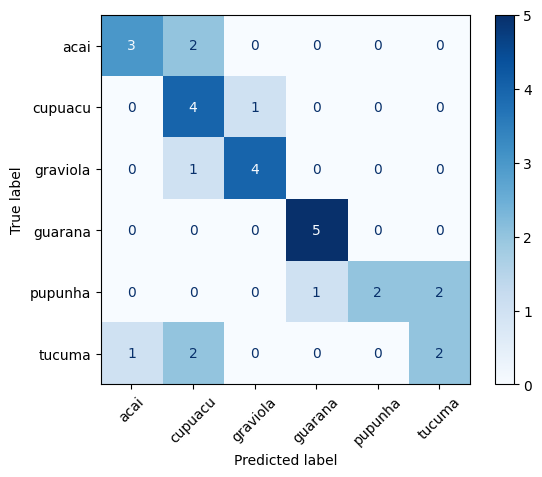

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    display_labels=test_class_names,
    cmap="Blues"
)
plt.xticks(rotation=45)
plt.show()

In [48]:
from PIL import Image, UnidentifiedImageError
import os

corrupted_images = [] # List to store corrupted images path

train_dir = TRAIN_DIR # Using the predefined TRAIN_DIR
class_names = train_class_names # Using the predefined train_class_names

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify() # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [49]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


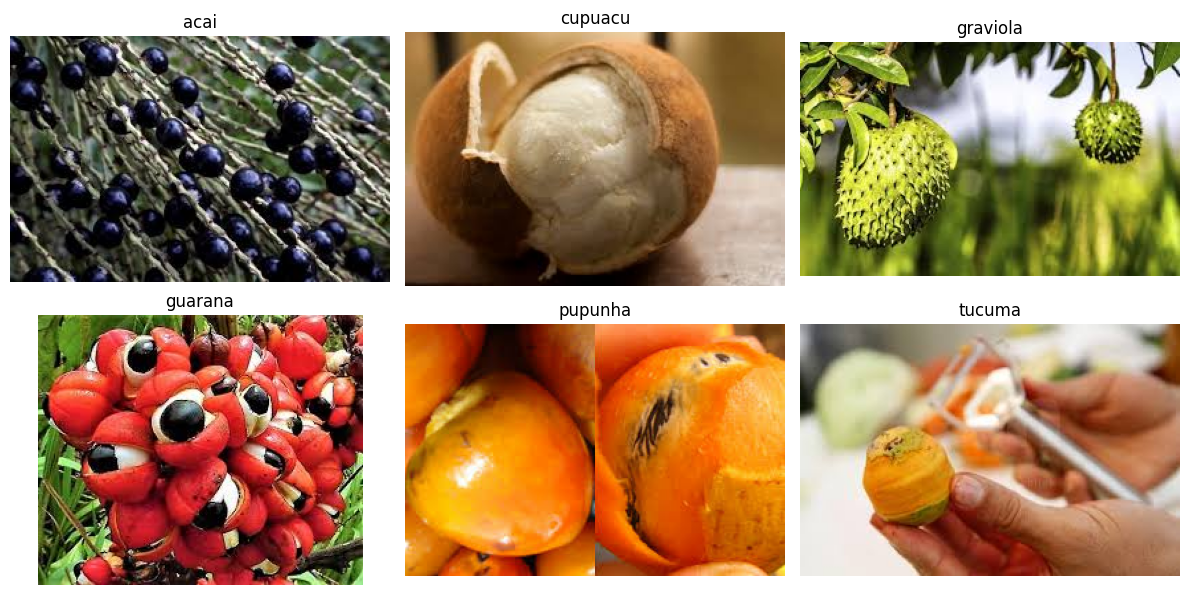

In [50]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

In [52]:
for images, labels in train_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 3)
Labels shape: (32,)


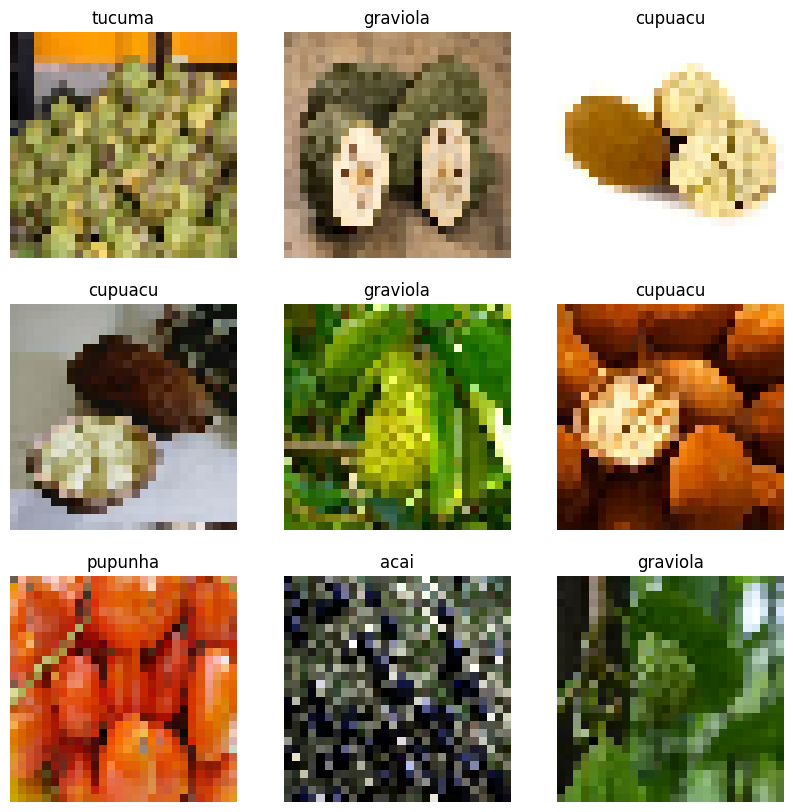

In [55]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])  # ✅ FIXED
        plt.title(train_class_names[labels[i]])
        plt.axis("off")

plt.show()

In [56]:
# This is a sample implementation, Thus I only use two augmentation, you can use more than two
# augmentation type for your project. Please check keras documentations for other available
# augmentation techniques.
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [57]:
model = keras.Sequential([
layers.Input(shape=(128, 128, 3)),
*data_augmentation_layers, # Include augmentation before the model layers
layers.Conv2D(32, (3,3), activation="relu"),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(10, activation="softmax")
])

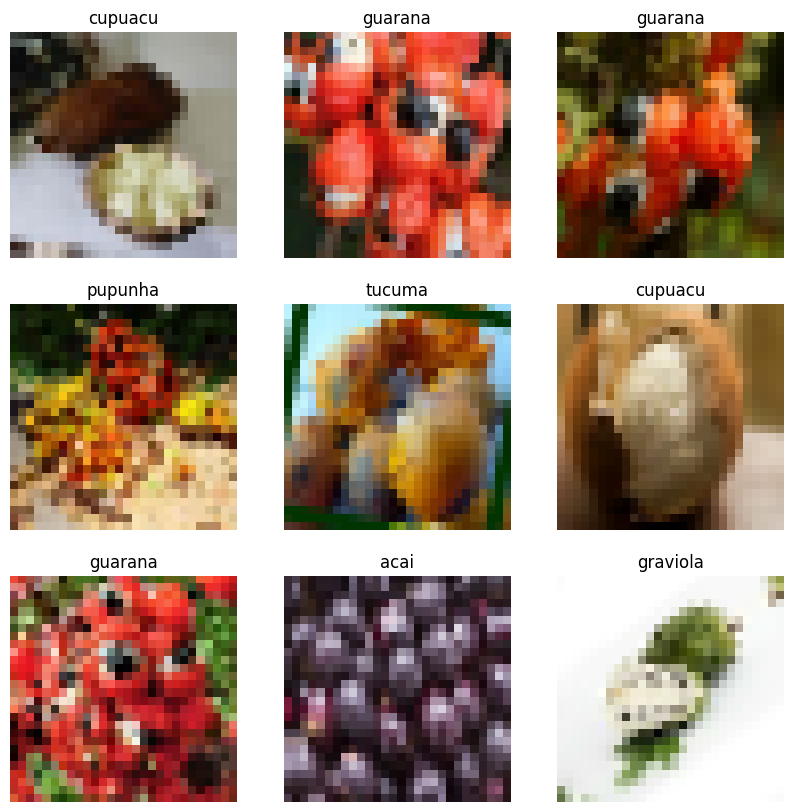

In [61]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i])
        plt.title(train_class_names[labels[i]])
        plt.axis("off")
plt.show()

In [64]:
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [65]:
model_augmented = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    *data_augmentation_layers, # Include augmentation layers
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax") # Use NUM_CLASSES for our fruit dataset
], name="Workshop5_Augmented")

model_augmented.summary()

Model: "Workshop5_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,702 (1.61 MB)

 Trainable params: 421,702 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_augmented.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [67]:
history_augmented = model_augmented.fit(
    augmented_train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1794 - loss: 1.8195
Epoch 1: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.1944 - loss: 1.8208 - val_accuracy: 0.0556 - val_loss: 1.8745
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2969 - loss: 1.6941 
Epoch 2: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2500 - loss: 1.7047 - val_accuracy: 0.1667 - val_loss: 1.8114
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3391 - loss: 1.6087 
Epoch 3: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3611 - loss: 1.5851 - val_accuracy: 0.1667 - val_loss: 1.7346
Epoch 4/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3438 - loss: 1.5175 
Epoch 4: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3889 - loss: 1.4626 - val_accuracy: 0.1667 - val_loss: 1.6751
Epoc

### Evaluate the Augmented Model

After training, I will evaluate the performance of the `model_augmented` on the `test_ds`.

In [68]:
print("\nEvaluating Augmented Model:")
loss_augmented, accuracy_augmented = model_augmented.evaluate(test_ds)
print(f"Test Loss (Augmented): {loss_augmented:.4f}")
print(f"Test Accuracy (Augmented): {accuracy_augmented:.4f}")


Evaluating Augmented Model:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2667 - loss: 1.7168
Test Loss (Augmented): 1.7168
Test Accuracy (Augmented): 0.2667


### Make Predictions with the Augmented Model

Finally, I will use the `model_augmented` to make predictions on the `test_ds` and display the classification report and confusion matrix.

In [69]:
predictions_augmented = model_augmented.predict(test_ds)
predicted_labels_augmented = np.argmax(predictions_augmented, axis=1)

print("\nClassification Report (Augmented Model):")
print(classification_report(true_labels, predicted_labels_augmented, target_names=test_class_names))

print("\nConfusion Matrix (Augmented Model):")
print(confusion_matrix(true_labels, predicted_labels_augmented))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

Classification Report (Augmented Model):
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       1.00      0.60      0.75         5
     guarana       0.19      1.00      0.31         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.27        30
   macro avg       0.20      0.27      0.18        30
weighted avg       0.20      0.27      0.18        30


Confusion Matrix (Augmented Model):
[[0 0 0 5 0 0]
 [0 0 0 5 0 0]
 [0 0 3 2 0 0]
 [0 0 0 5 0 0]
 [0 0 0 5 0 0]
 [0 0 0 5 0 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


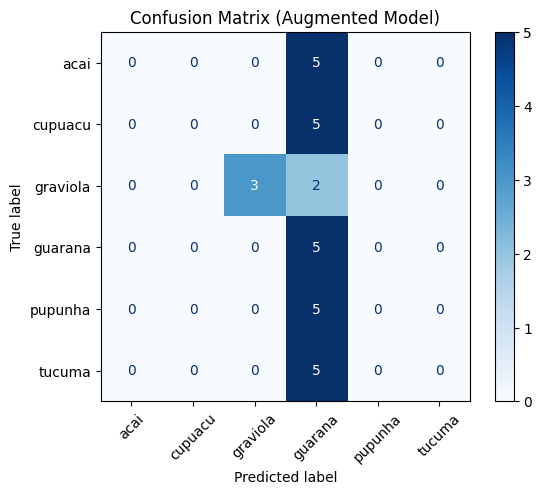

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels_augmented,
    display_labels=test_class_names,
    cmap="Blues"
)
plt.xticks(rotation=45)
plt.title("Confusion Matrix (Augmented Model)")
plt.show()

In [71]:
from tensorflow.keras.layers import BatchNormalization
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
beta_initializer="zeros", gamma_initializer="ones")

In [73]:
from tensorflow.keras.layers import Dropout
layer = Dropout(rate, noise_shape=None, seed=None)

NameError: name 'rate' is not defined

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Define the model using the Sequential API with a list of layers
model_complex_augmented = Sequential([
    # Data augmentation applied directly
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    *data_augmentation_layers,
    # NOTE: Rescaling is removed as datasets are already normalized (0-1)

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer with NUM_CLASSES neurons (for classification task)
    Dense(NUM_CLASSES, activation='softmax')
], name="Complex_Augmented_Model")

# Compile the model
model_complex_augmented.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use this for integer labels
    metrics=['accuracy']
)

# Summary of the model
model_complex_augmented.summary()

Model: "Complex_Augmented_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 28, 28, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 698,630 (2.67 MB)

 Trainable params: 695,750 (2.65 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [75]:
history_complex_augmented = model_complex_augmented.fit(
    augmented_train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

Epoch 1/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1328 - loss: 2.5753
Epoch 1: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 341ms/step - accuracy: 0.1250 - loss: 2.4834 - val_accuracy: 0.1667 - val_loss: 1.7919
Epoch 2/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.1719 - loss: 2.2779
Epoch 2: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2083 - loss: 2.2342 - val_accuracy: 0.2222 - val_loss: 1.7897
Epoch 3/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1172 - loss: 2.5972
Epoch 3: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.1389 - loss: 2.4327 - val_accuracy: 0.2222 - val_loss: 1.7858
Epoch 4/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1172 - loss: 2.5425
Epoch 4: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.1528 - loss: 2.4364 - val_accuracy: 0.2778 - val_loss: 1.7819


In [76]:
IMG_HEIGHT_VGG = 224
IMG_WIDTH_VGG = 224

# Function to resize images
def resize_and_rescale(image, label):
    image = tf.image.resize(image, [IMG_HEIGHT_VGG, IMG_WIDTH_VGG])
    return image, label

# Apply resizing to all datasets
train_ds_resized = train_ds_raw.map(resize_and_rescale)
val_ds_resized = val_ds_raw.map(resize_and_rescale)
test_ds_resized = test_ds_raw.map(resize_and_rescale)

# Re-apply normalization after resizing
train_ds_resized = train_ds_resized.map(lambda x, y: (rescale(x), y))
val_ds_resized = val_ds_resized.map(lambda x, y: (rescale(x), y))
test_ds_resized = test_ds_resized.map(lambda x, y: (rescale(x), y))

print(f"Resized training dataset image shape example: {next(iter(train_ds_resized))[0].shape}")
print(f"Resized validation dataset image shape example: {next(iter(val_ds_resized))[0].shape}")
print(f"Resized test dataset image shape example: {next(iter(test_ds_resized))[0].shape}")

Resized training dataset image shape example: (32, 224, 224, 3)
Resized validation dataset image shape example: (18, 224, 224, 3)
Resized test dataset image shape example: (30, 224, 224, 3)


In [77]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# 1. Load the Pre-trained Model (VGG16)
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG, 3))

# 2. Freeze the Layers
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# 3. Add Custom Layers
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(NUM_CLASSES, activation='softmax')(x) # Output layer for our NUM_CLASSES (6) classes

# 4. Create the Final Model
model_transfer_learning = Model(inputs=base_model.input, outputs=x)

model_transfer_learning.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model_transfer_learning.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

history_transfer_learning = model_transfer_learning.fit(
    train_ds_resized,
    epochs=EPOCHS,
    validation_data=val_ds_resized,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6053 - loss: 1.2517 
Epoch 1: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 18s/step - accuracy: 0.5972 - loss: 1.2666 - val_accuracy: 0.3333 - val_loss: 1.6980
Epoch 2/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 20s 21s/step - accuracy: 0.5391 - loss: 1.2023